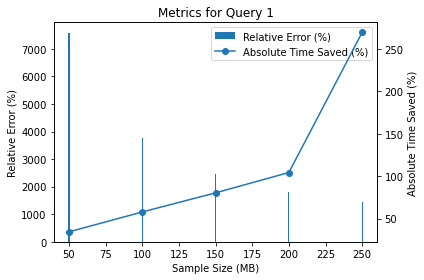

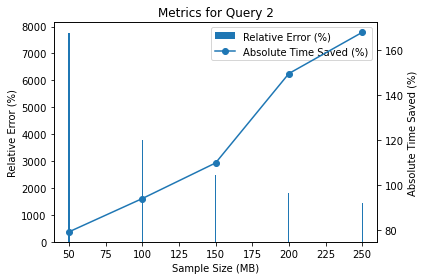

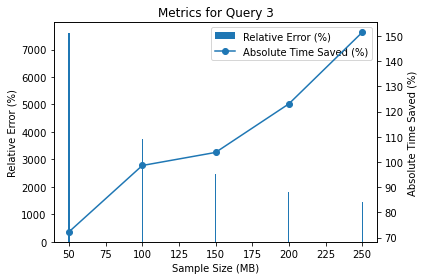

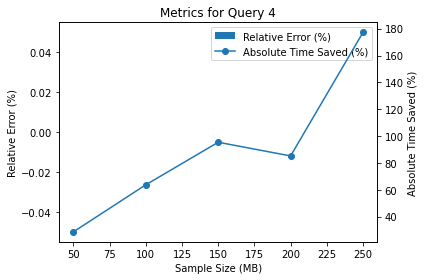

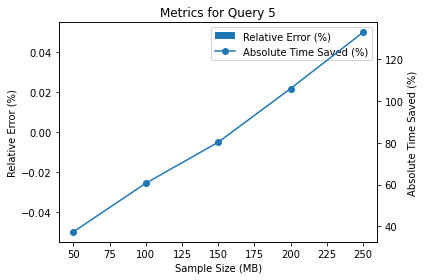

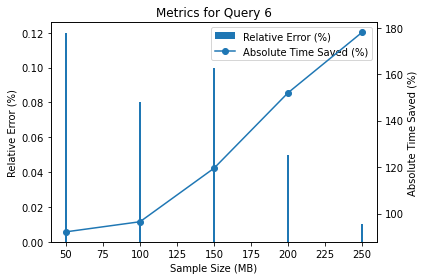

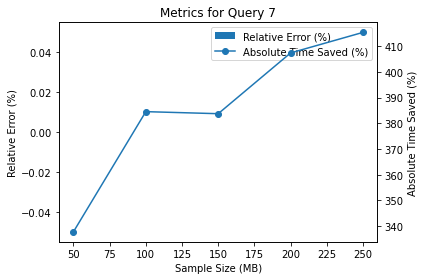

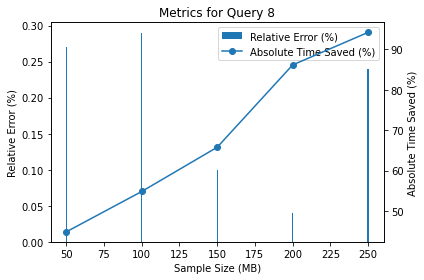

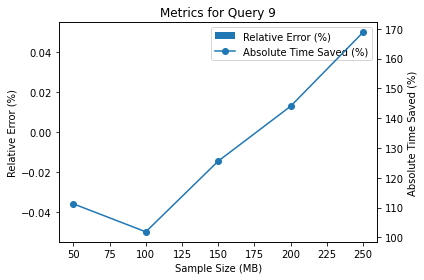

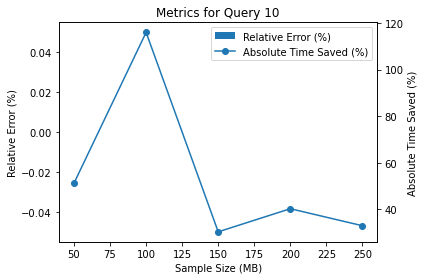

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv('errors_overhead.csv')

# Dynamically detect columns
query_col = next(col for col in df.columns if 'query' in col.lower())
sample_col = next(col for col in df.columns if 'db' in col.lower() or 'database' in col.lower() or 'size' in col.lower())
error_col = next(col for col in df.columns if 'error' in col.lower())
time_col = next(col for col in df.columns if 'saved' in col.lower() or 'overhead' in col.lower())

# Extract numeric sample size in MB
df['MB'] = df[sample_col].astype(str).str.extract(r'(\d+)').astype(int)

# Convert metrics to numeric and make time saved absolute
df[error_col] = pd.to_numeric(df[error_col], errors='coerce')
df[time_col] = pd.to_numeric(df[time_col], errors='coerce').abs()

# Plot combined metrics for each query
for idx, q in enumerate(df[query_col].unique(), start=1):
    sub = df[df[query_col] == q].sort_values('MB')
    
    fig, ax1 = plt.subplots()
    ax1.bar(sub['MB'], sub[error_col], label='Relative Error (%)')
    ax1.set_xlabel('Sample Size (MB)')
    ax1.set_ylabel('Relative Error (%)')
    
    ax2 = ax1.twinx()
    ax2.plot(sub['MB'], sub[time_col], marker='o', label='Absolute Time Saved (%)')
    ax2.set_ylabel('Absolute Time Saved (%)')
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    plt.title(f'Metrics for Query {idx}')
    plt.tight_layout()
    plt.show()
